# FINANCE 384 --- Lecture 2

## The Pooled Benchmark Workflow: Split, Forecast, Rank, Trade

This is the second notebook for Lecture 2. The first,
`FINANCE384_Lecture2_PooledRegression.ipynb`, builds the panel and estimates the pooled
regression. This one takes that same model and asks the question an investment team would
ask: **does it work on months it has never seen?**

The model does not change:

$$r^e_{i,t+1} = \alpha + \beta_1\,\text{Size}_{i,t} + \beta_2\,\text{BM}_{i,t}
+ \beta_3\,\text{Mom}_{i,t} + \varepsilon_{i,t+1}$$

Sections 1--4 repeat the first notebook: load the panel, validate it, sort it, and build
the $t+1$ target. Section 5 onwards is new:

1. split the months into an estimation sample and an evaluation sample;
2. measure forecast accuracy on the evaluation months;
3. measure whether the forecasts **rank** stocks correctly;
4. turn the ranking into portfolios and see whether it makes money.


## Learning objectives

After working through this notebook you should be able to:

1. split a stock-month panel by calendar time
2. estimate the benchmark on training months only, and forecast the held-out months
3. compare forecast accuracy against simple benchmarks using MSE, MAE, and $R^2$
4. measure ranking quality with a within-month rank correlation, and interpret its sign
5. sort forecasts into decile portfolios and form a high-minus-low strategy
6. test whether the strategy's return is exposure to known factors


## 1. Imports and settings

`scikit-learn` fits the model and produces forecasts. `statsmodels` appears only where we
need standard errors and $t$-statistics, which `scikit-learn` does not report.



In [ ]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

pd.set_option("display.precision", 5)
plt.rcParams["figure.figsize"] = (9, 4)
plt.rcParams["axes.grid"] = True

FEATURES = ["size", "bm", "mom12_2"]     # characteristics known at the end of month t
TRAIN_END = pd.Timestamp("2016-12-31")   # last decision month used for estimation
N_PORTFOLIOS = 10                        # deciles

# The factor returns of Section 9.3 live in the shared project Data/ folder. In Colab,
# upload them next to the notebook and this falls back to the current folder.
DATA_DIR = Path("../../Data") if Path("../../Data").exists() else Path(".")

## 2. The data

`FINANCE384_topic1_lecture_panel.csv` is a monthly panel of S&P 500 stocks: 141,886 rows, 1,030 stocks, January 2000 to December 2024, and roughly 470
stocks in any one month. One row is one stock-month $(i, t)$ --- stock $i$ observed at the
end of month $t$. The panel is **unbalanced**: index membership changes, so stocks enter
and leave and no stock is present for all 300 months.

| Column | Meaning | Timing |
|---|---|---|
| `permno` | CRSP stock identifier --- the unit $i$ | identifier |
| `date` | last trading day of decision month $t$ | identifier |
| `ticker`, `comnam`, `exchcd`, `siccd`, `gvkey` | security and firm labels | identifier |
| `industry`, `ff49_code`, `ff49_name` | industry classification | known at $t$ |
| `size` | log market capitalisation | known at $t$ |
| `bm` | book equity (6-month availability lag) / market capitalisation | known at $t$ |
| `mom12_2` | cumulative return over months $t-11$ to $t-1$, skipping month $t$ | known at $t$ |
| `down_market` | 1 if the trailing 12-month market excess return is negative | known at $t$ |
| `ret_excess_t` | delisting-adjusted return in excess of the risk-free rate | earned over $t$ |

**What `ret_excess_t` measures.** It is the return earned *over* month $t$, and therefore
known *at* the end of month $t$, which is the decision date. It is an outcome for month
$t$, not a forecast of month $t+1$.


In [2]:
# Import the data


Rows           : 141,886
Distinct stocks: 1,030
Months         : 300 (2000-01 to 2024-12)


,date,permno,ticker,comnam,exchcd,siccd,industry,ff49_code,ff49_name,gvkey,size,bm,mom12_2,down_market,ret_excess_t
0,2000-01-31,10078,SUNW,SUN MICROSYSTEMS INC,3,3571,Manufacturing,34,BusSv,12136,25.53255,0.03923,1.77181,0,0.01043
1,2000-02-29,10078,SUNW,SUN MICROSYSTEMS INC,3,3571,Manufacturing,34,BusSv,12136,25.72517,0.03236,2.22929,0,0.20811
2,2000-03-31,10078,SUNW,SUN MICROSYSTEMS INC,3,3571,Manufacturing,34,BusSv,12136,25.72487,0.03237,2.04648,0,-0.02094
3,2000-04-28,10078,SUNW,SUN MICROSYSTEMS INC,3,3571,Manufacturing,34,BusSv,12136,25.70724,0.03295,2.13323,0,-0.02344
4,2000-05-31,10078,SUNW,SUN MICROSYSTEMS INC,3,3571,Manufacturing,34,BusSv,12136,25.52506,0.03953,2.07741,0,-0.17155


## 3. Validate before modelling

Four checks worth doing every time: one row per stock-month, confirmation that the panel
really is unbalanced, no missing values in the columns we model with, and feature values
that look sensible.


In [3]:
# Validate the data

Duplicate (permno, date) rows: 0
Stocks per month : 450 to 488 (mean 473)
Months per stock : 1 to 300 (median 108)   -> unbalanced

Missing values:
size            0
bm              0
mom12_2         0
ret_excess_t    0
dtype: int64

Feature summary:


,size,bm,mom12_2,ret_excess_t
mean,23.52397,0.50096,0.10589,0.00790
std,1.18870,0.61459,0.34919,0.09918
min,18.57262,0.00005,-0.98957,-0.97963
max,28.96215,84.79661,10.43800,2.62663


## 4. Sorting and the prediction target

### 4.1 Sort first

Sorting by stock and then date puts each stock's history in calendar order, which is what
makes any within-stock operation mean what it says.

Sorting also makes the panel's two directions visible, and they matter throughout:

- `groupby("permno")` moves **down one stock through time** --- used below to attach next
  month's return;
- `groupby("date")` moves **across the stocks in one month** --- used in Sections 8 and 9
  to rank stocks against the others available that month.


In [4]:
# Sort the data


,permno,date,ticker,size,bm,mom12_2,ret_excess_t
0,10078,2000-01-31,SUNW,25.53255,0.03923,1.77181,0.01043
1,10078,2000-02-29,SUNW,25.72517,0.03236,2.22929,0.20811
2,10078,2000-03-31,SUNW,25.72487,0.03237,2.04648,-0.02094
3,10078,2000-04-28,SUNW,25.70724,0.03295,2.13323,-0.02344
4,10078,2000-05-31,SUNW,25.52506,0.03953,2.07741,-0.17155


### 4.2 Attaching next month's return

We want the return earned over month $t+1$ sitting on month $t$'s row:

$$\text{target}_{i,t} = r^e_{i,t+1}.$$

Build it with a calendar join. Take each stock-month's return, relabel it with the
decision month it settles ($t = $ its own month minus one), and merge it back on
`(permno, month)`. Because the join is by calendar month, a stock that leaves the index
and rejoins years later simply fails to match, and its target is `NaN`.

Two details make this safe:

- `date.dt.to_period("M")` turns a month-end date into a calendar month, so `- 1` is month
  arithmetic;
- `validate="one_to_one"` makes pandas raise if either side has duplicate keys, rather than
  silently duplicating rows.


In [5]:
# Form the target


Rows                 : 141,886
Usable targets       : 140,786
No month t+1 in data : 1,100


,permno,month,ret_excess_t,target_ret_excess_tp1
0,10078,2000-01,0.01043,0.20811
1,10078,2000-02,0.20811,-0.02094
2,10078,2000-03,-0.02094,-0.02344
3,10078,2000-04,-0.02344,-0.17155
4,10078,2000-05,-0.17155,0.18279


### 4.3 The modelling sample

Keep the rows that have a target. `ret_excess_t` has done its job: it is a legitimate
time-$t$ predictor, but the benchmark specification is size, value, and momentum only, so
leaving it in the frame would invite it into the feature matrix later.


In [6]:
# Finalise the data sample


stock_months   : 140,786 rows x 1,029 stocks
Decision months: 2000-01 to 2024-11


## 5. Train and test months

Everything so far has been shared with the first notebook. This is where they diverge.

A forecast is a claim about months the model has never seen, so the evaluation months must
come *after* the estimation months:

- **train** --- decision months 2000-01 to 2016-12, used to estimate the coefficients;
- **test** --- decision months 2017-01 onward, used only to score the forecasts.

**Why not split the rows at random?** A random split puts the same month on both sides, so
the model would be tested on stocks whose market-wide shock it had already fitted on their
neighbours. The test months would no longer be a genuine future.


In [7]:
train = stock_months.loc[stock_months["date"] <= TRAIN_END].copy()
test = stock_months.loc[stock_months["date"] > TRAIN_END].copy()

for name, sample in [("train", train), ("test", test)]:
    print(f"{name:<6}: {sample['date'].min():%Y-%m} to {sample['date'].max():%Y-%m}  "
          f"{len(sample):>7,} rows  {sample['date'].nunique():>4} months  "
          f"{sample['permno'].nunique():>5,} stocks")


train : 2000-01 to 2016-12   96,750 rows   204 months    886 stocks
test  : 2017-01 to 2024-11   44,036 rows    95 months    624 stocks


## 6. The pooled benchmark

Pooled OLS on the stacked training rows: one intercept and one slope vector for every
stock and every month.


In [8]:
benchmark = LinearRegression().fit(train[FEATURES], train[TARGET])

pd.Series(np.r_[benchmark.intercept_, benchmark.coef_],
          index=["intercept"] + FEATURES).round(5)


intercept    0.06408
size        -0.00269
bm           0.01143
mom12_2      0.00211
dtype: float64

`scikit-learn` gives the estimates but no standard errors, so `statsmodels` refits the
same regression for inference. Standard errors are clustered by decision month: every
stock in a month shares that month's market-wide news, so the rows are not independent
draws and the textbook formula would overstate precision.


In [9]:
benchmark_inference = sm.OLS(train[TARGET], sm.add_constant(train[FEATURES])).fit(
    cov_type="cluster", cov_kwds={"groups": train["date"]}
)

print(f"Training rows = {len(train):,}   months = {train['date'].nunique()}   "
      f"R-squared = {benchmark_inference.rsquared:.4f}\n")
pd.DataFrame({
    "coef": benchmark_inference.params,
    "std err": benchmark_inference.bse,
    "t": benchmark_inference.tvalues,
}).round(5)


Training rows = 96,750   months = 204   R-squared = 0.0072



,coef,std err,t
const,0.06408,0.02997,2.13801
size,-0.00269,0.00120,-2.23523
bm,0.01143,0.00418,2.73320
mom12_2,0.00211,0.00850,0.24805


**Reading the output.** 
The $R^2$ is tiny, which is normal for monthly stock returns --- almost all of the
variation is noise no model can predict. That does not settle anything yet. These are
in-sample associations, and a model can fit the past without forecasting the future.


## 7. Forecast accuracy on the test months

Freeze the coefficients, forecast every test stock-month, and compare against two
forecasts that need no model at all:

- **zero** --- every excess return predicted to be zero;
- **training mean** --- the average training target, and nothing else.

Three measures:

- **RMSE** --- typical error size, penalising large misses most;
- **MAE** --- typical error size, treating all misses equally;
- **$R^2$** --- the share of the variation in realised returns the forecasts explain. It
  is $0$ when a forecast does no better than predicting the sample average, and
  **negative** when it does worse.


In [10]:
test["forecast"] = benchmark.predict(test[FEATURES])
training_mean = train[TARGET].mean()

actual = test[TARGET]
candidates = {
    "zero": np.zeros(len(test)),
    "training mean": np.full(len(test), training_mean),
    "pooled OLS benchmark": test["forecast"].to_numpy(),
}

accuracy = pd.DataFrame({
    "RMSE": {name: np.sqrt(mean_squared_error(actual, f)) for name, f in candidates.items()},
    "MAE": {name: mean_absolute_error(actual, f) for name, f in candidates.items()},
    "R2": {name: r2_score(actual, f) for name, f in candidates.items()},
})
accuracy.round(5)


,RMSE,MAE,R2
zero,0.09126,0.06640,-0.00890
training mean,0.09086,0.06595,-0.00004
pooled OLS benchmark,0.09098,0.06618,-0.00273


The three RMSEs sit within a few basis points of each other, and every $R^2$ is at or
below zero: the benchmark did not beat simply predicting the average return.

Which is why accuracy is only the first question. A portfolio manager does not need the
*level* of each return to be right --- only the *order*.


## 8. Ranking quality: rank correlation

Each test month, rank the stocks by forecast and rank them again by the return they
actually earned, then measure how closely the two orderings agree. That is the **Spearman
rank correlation**, and `groupby("date")` computes it one month at a time.

Spearman rather than Pearson because only the ordering matters, not the size of the gaps.

**Reading the sign.** The correlation runs from $-1$ to $+1$:

- **positive** --- the ordering was right: the stocks the model preferred did better than
  the ones it disliked. This is what a usable signal looks like. Because monthly returns
  are mostly noise, even a small positive average is worth having.
- **zero** --- the ranking carried no information; it did no better than shuffling the
  stocks at random.
- **negative** --- the ordering was backwards: the stocks the model preferred did *worse*.

One number per month also lets us ask how *often* it was positive. A signal that works in
only a handful of months is not one a team would trade.


In [11]:
monthly_spearman = (
    test.groupby("date")[["forecast", TARGET]]
        .apply(lambda month: month["forecast"].corr(month[TARGET], method="spearman"))
        .rename("spearman")
)

print(f"Test months          : {len(monthly_spearman)}")
print(f"Mean rank correlation: {monthly_spearman.mean():.4f}")
print(f"Months positive      : {(monthly_spearman > 0).mean():.0%}")


Test months          : 95
Mean rank correlation: -0.0211
Months positive      : 49%


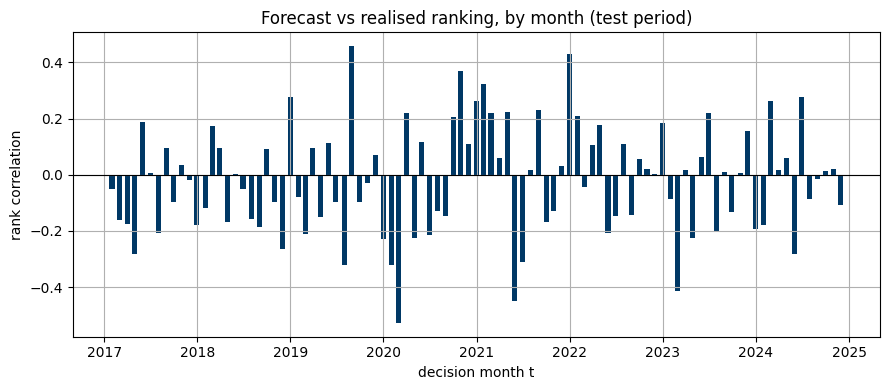

In [ ]:
fig, ax = plt.subplots()
ax.bar(monthly_spearman.index, monthly_spearman.to_numpy(), width=20, color='tab:blue')
ax.axhline(0, color="black", lw=0.8)
ax.set_xlabel("decision month t")
ax.set_ylabel("rank correlation")
ax.set_title("Forecast vs realised ranking, by month (test period)")
plt.tight_layout()
plt.show()


## 9. From a ranking to a portfolio

### 9.1 Decile portfolios

Each test month, sort the stocks into ten equal-sized groups by forecast and record what
each group earned over month $t+1$. Sorting inside `groupby("date")` keeps a stock ranked
only against the stocks available in the *same* decision month.

A model with useful forecasts produces average returns that rise from decile 1 to
decile 10.


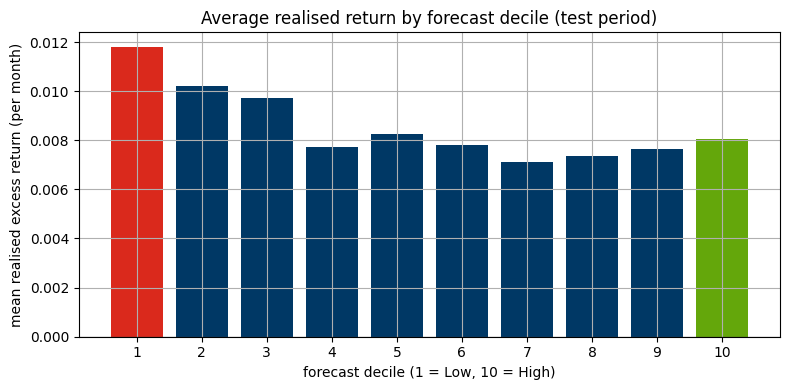

decile
1     0.01180
2     0.01019
3     0.00972
4     0.00772
5     0.00827
6     0.00783
7     0.00710
8     0.00737
9     0.00766
10    0.00806
dtype: float64

In [ ]:
test["decile"] = test.groupby("date")["forecast"].transform(
    lambda f: pd.qcut(f.rank(method="first"), N_PORTFOLIOS, labels=False) + 1
)

# Mean return per decile per month, then averaged across months so every month counts
# equally rather than letting months with more stocks dominate.
decile_monthly = test.groupby(["date", "decile"])[TARGET].mean().unstack()
decile_profile = decile_monthly.mean()

fig, ax = plt.subplots(figsize=(8, 4))
colors = ['tab:red' if d == 1 else 'tab:green' if d == N_PORTFOLIOS else 'tab:blue'
          for d in decile_profile.index]
ax.bar(decile_profile.index, decile_profile.to_numpy(), color=colors)
ax.axhline(0, color="black", lw=0.8)
ax.set_xlabel(f"forecast decile (1 = Low, {N_PORTFOLIOS} = High)")
ax.set_ylabel("mean realised excess return (per month)")
ax.set_title("Average realised return by forecast decile (test period)")
ax.set_xticks(decile_profile.index)
plt.tight_layout()
plt.show()

decile_profile.round(5)


### 9.2 The high-minus-low portfolio

Buy the top decile, short the bottom decile, and hold for month $t+1$. The short leg
finances the long leg, so this is a stylised zero-net-investment test of the signal itself.

The ranking decides *which* stocks; the weighting rule decides *how much* each one gets:

- **equal-weighted** --- the same capital in every name, which tilts towards smaller, less
  liquid stocks;
- **value-weighted** --- capital in proportion to market capitalisation, which is more
  realistic for a large fund. `size` is *log* market capitalisation, so `np.exp(size)`
  recovers the level.

The **Sharpe ratio** annualises return per unit of volatility, so higher is better and a
negative Sharpe means the strategy lost money.


In [14]:
legs = test.loc[test["decile"].isin([1, N_PORTFOLIOS])].copy()
legs["leg"] = np.where(legs["decile"].eq(N_PORTFOLIOS), "High", "Low")

# Two weighting rules, each summing to one inside each leg of each month
legs["ew_w"] = 1 / legs.groupby(["date", "leg"])["permno"].transform("count")
legs["mktcap"] = np.exp(legs["size"])
legs["vw_w"] = legs["mktcap"] / legs.groupby(["date", "leg"])["mktcap"].transform("sum")

legs["ew_contrib"] = legs["ew_w"] * legs[TARGET]
legs["vw_contrib"] = legs["vw_w"] * legs[TARGET]

leg_returns = (
    legs.groupby(["date", "leg"])[["ew_contrib", "vw_contrib"]].sum().unstack("leg")
)
hl_equal = (leg_returns[("ew_contrib", "High")] - leg_returns[("ew_contrib", "Low")]).rename("hl")
hl_value = (leg_returns[("vw_contrib", "High")] - leg_returns[("vw_contrib", "Low")]).rename("hl")

summary = {}
for label, monthly in [("equal-weighted", hl_equal), ("value-weighted", hl_value)]:
    mean_annual = monthly.mean() * 12
    vol_annual = monthly.std(ddof=1) * np.sqrt(12)
    summary[label] = {
        "annualised mean": mean_annual,
        "annualised volatility": vol_annual,
        "annualised Sharpe": mean_annual / vol_annual,
    }

pd.DataFrame(summary).T.round(4)


,annualised mean,annualised volatility,annualised Sharpe
equal-weighted,-0.0449,0.2235,-0.2009
value-weighted,-0.0835,0.2208,-0.3781


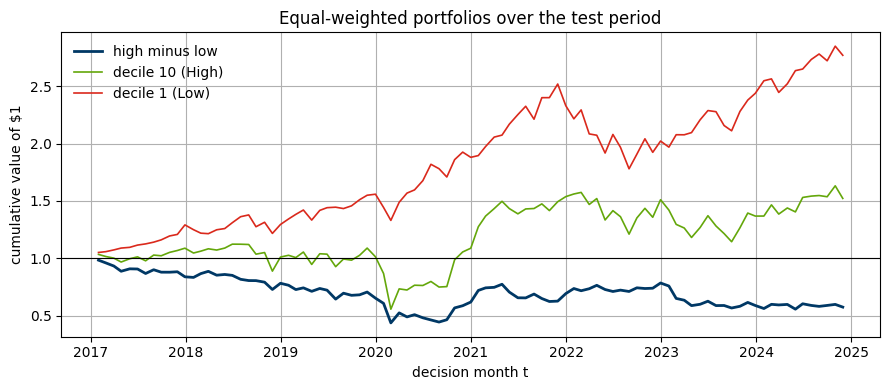

In [ ]:
fig, ax = plt.subplots()
ax.plot(hl_equal.index, (1 + hl_equal).cumprod(), color='tab:blue', lw=2,
        label="high minus low")
ax.plot(decile_monthly.index, (1 + decile_monthly[N_PORTFOLIOS]).cumprod(),
        color='tab:green', lw=1.2, label=f"decile {N_PORTFOLIOS} (High)")
ax.plot(decile_monthly.index, (1 + decile_monthly[1]).cumprod(),
        color='tab:red', lw=1.2, label="decile 1 (Low)")
ax.axhline(1, color="black", lw=0.8)
ax.set_xlabel("decision month t")
ax.set_ylabel("cumulative value of $1")
ax.set_title("Equal-weighted portfolios over the test period")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()


### 9.3 Alpha: is the return just factor exposure?

A strategy can earn a return simply by holding well-known risks. To separate the two,
regress the realised high-minus-low return on the factor returns of the **same holding
month**:

$$r^{HL}_{t+1} = \alpha + \beta' f_{t+1} + e_{t+1}.$$

The intercept $\alpha$ is what is left after the factor exposures are removed --- the part
the signal can claim as its own.

Using next month's factor returns here is legitimate, and using them as a *forecast input*
would not be: this is attribution after the returns are realised, not prediction. A
portfolio formed at the end of month $t$ earns its return during month $t+1$, so it is
matched to month $t+1$'s factors. Since the signal itself contains momentum, the FF5 +
momentum row is the most demanding of the three tests.


In [16]:
FACTORS = ["mktrf", "smb", "hml", "rmw", "cma", "umd"]

factors = pd.read_csv(DATA_DIR / "FINANCE384_ff5_momentum_monthly.csv", parse_dates=["date"])
factors["holding_month"] = factors["date"].dt.to_period("M")

# Formed at the end of month t, held through month t+1: match on t+1.
hl_factors = hl_equal.reset_index()
hl_factors["holding_month"] = hl_factors["date"].dt.to_period("M") + 1
hl_factors = hl_factors.merge(factors[["holding_month"] + FACTORS], on="holding_month",
                              how="left", validate="one_to_one")

models = {
    "CAPM": ["mktrf"],
    "Fama-French 3-factor": ["mktrf", "smb", "hml"],
    "FF5 + momentum": FACTORS,
}

alphas = {}
for name, regressors in models.items():
    fit = sm.OLS(hl_factors["hl"], sm.add_constant(hl_factors[regressors])).fit()
    alphas[name] = {
        "annualised alpha": fit.params["const"] * 12,
        "t-statistic": fit.tvalues["const"],
        "market beta": fit.params["mktrf"],
        "R2": fit.rsquared,
    }

pd.DataFrame(alphas).T.round(4)


,annualised alpha,t-statistic,market beta,R2
CAPM,-0.1116,-1.4817,0.5189,0.1522
Fama-French 3-factor,-0.0314,-0.7685,0.3254,0.7611
FF5 + momentum,-0.0001,-0.0016,0.2432,0.8125


## 10. From output to decision

A research team does not report four metrics; it reaches a recommendation. Read the
evidence as one piece:

| Evidence | Section | The question it answers |
|---|---|---|
| RMSE, MAE, $R^2$ | 7 | Does the benchmark beat a zero or average forecast? |
| Rank correlation | 8 | Does it order stocks within a month, and in how many months? |
| Decile profile | 9.1 | Do average returns rise from decile 1 to decile 10? |
| High minus low, Sharpe | 9.2 | Is the spread positive and large relative to its risk? |
| Alpha | 9.3 | Does anything survive adjustment for known factors? |

Notice how the rungs interact. Coefficients can be statistically significant in the
training months while the forecasts fail out of sample, and a return that disappears once
factors are removed was never a new signal --- only a repackaged old one. Any one of these
read alone would mislead.

Then answer the question the team actually faces: is this model good enough to use on its
own, or is its job to be the **hurdle** that a richer model must clear? In FINANCE 384 it
is the second. Lectures 3--6 return to this same evaluation on this same panel, and the
question each time is not "does the new model fit better?" but "does it clear this bar by
enough to justify its complexity?"


## Extension questions

1. **Fewer, bigger buckets.** Set `N_PORTFOLIOS = 5`. Quintiles hold more stocks per leg
   and so are better diversified. Does the high-minus-low result change?
2. **A different split.** Move `TRAIN_END` to 2012 or 2020. How stable are the
   coefficients, and the conclusion?
